# RetailPulse - Customer Behavior Analytics & Revenue Intelligence Platform

## Day 5 - Customer Segmentation (K-Means Clustering)

### Objectives
- K-Means clustering on RFM features
- Elbow method and silhouette score for K selection (justified, not arbitrary)
- Cluster business profiling (4 segments)
- MLflow experiment tracking for the clustering run


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import mlflow
import mlflow.sklearn
import joblib
import warnings

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

mlflow.set_tracking_uri("sqlite:///../mlruns/mlflow.db")
mlflow.set_experiment("RetailPulse_Segmentation")

print("MLflow tracking URI:", mlflow.get_tracking_uri())

2026/07/30 13:28:31 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/30 13:28:31 INFO mlflow.store.db.utils: Updating database tables
2026/07/30 13:28:33 INFO mlflow.tracking.fluent: Experiment with name 'RetailPulse_Segmentation' does not exist. Creating a new experiment.


MLflow tracking URI: sqlite:///../mlruns/mlflow.db


In [3]:
rfm = pd.read_csv("../data/processed/customer_features.csv")
print("Shape:", rfm.shape)
rfm.head()

Shape: (5878, 18)


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,TenureDays,AvgOrderValue,PurchaseFrequencyPerYear,CLV_Approx,UniqueProducts,TotalItemsPurchased,AvgItemsPerOrder,WeekendOrderRatio,PrimaryCountry
0,12346,326,12,580.86,2,5,2,252,9,400,48.405,10.957500,580.86,27,270,7.941176,0.000000,United Kingdom
1,12347,2,8,5591.72,5,4,5,545,14,402,698.965,7.268657,5591.72,126,3246,12.830040,0.158103,Iceland
2,12348,75,5,1821.40,3,4,4,344,11,362,364.280,5.044890,1821.40,25,2714,53.215686,0.058824,Finland
3,12349,19,4,3642.94,5,3,5,535,13,570,910.735,2.563158,3642.94,138,1624,9.280000,0.000000,Italy
4,12350,310,1,312.40,2,1,2,212,5,1,312.400,365.250000,312.40,17,197,11.588235,0.000000,Norway


## 1. Scale RFM features for clustering

In [4]:
features = ["Recency", "Frequency", "Monetary"]
X = rfm[features].copy()

# Monetary and Frequency are right-skewed - log-transform before scaling
X["Frequency"] = np.log1p(X["Frequency"])
X["Monetary"] = np.log1p(X["Monetary"].clip(lower=0))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled feature shape:", X_scaled.shape)

Scaled feature shape: (5878, 3)


## 2. Elbow Method + Silhouette Score (K selection)

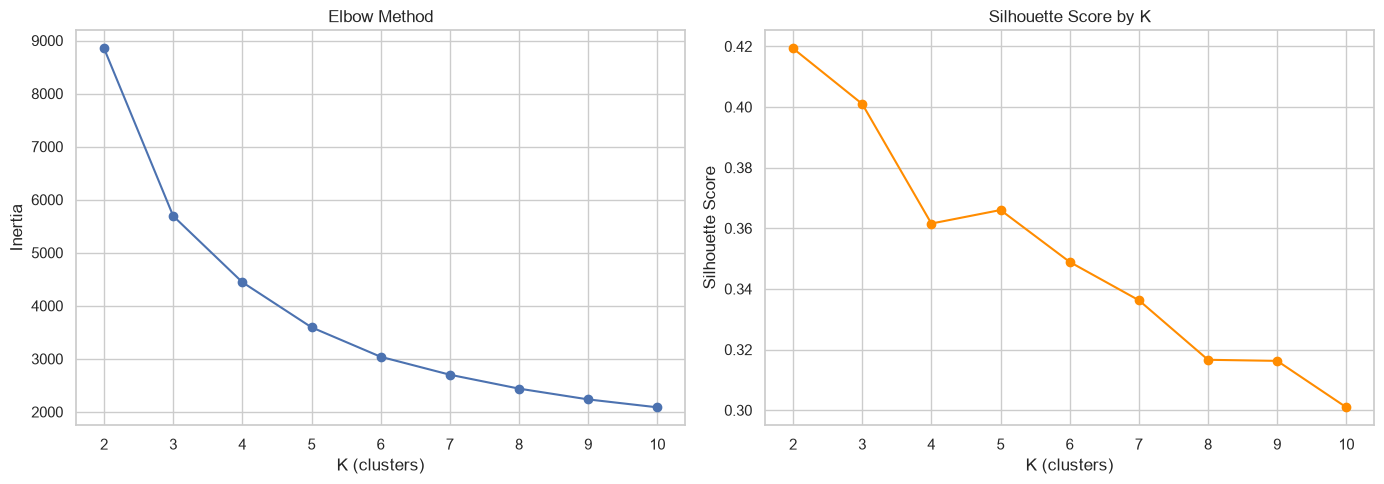

K=2: silhouette=0.4193
K=3: silhouette=0.4010
K=4: silhouette=0.3616
K=5: silhouette=0.3660
K=6: silhouette=0.3489
K=7: silhouette=0.3363
K=8: silhouette=0.3166
K=9: silhouette=0.3163
K=10: silhouette=0.3010


In [5]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set(title="Elbow Method", xlabel="K (clusters)", ylabel="Inertia")
axes[1].plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
axes[1].set(title="Silhouette Score by K", xlabel="K (clusters)", ylabel="Silhouette Score")
plt.tight_layout()
plt.savefig("../reports/segmentation_k_selection.png", dpi=120)
plt.show()

for k, sil in zip(k_range, silhouette_scores):
    print(f"K={k}: silhouette={sil:.4f}")

### K selection justification
The brief calls for 4 business segments. We check where K=4 falls on both curves: the elbow plot should show inertia flattening around K=4, and the silhouette score should be reasonably high (>0.3 is acceptable for real-world retail RFM data, which rarely has perfectly separated clusters). If K=4 is not the silhouette-optimal K, we note the discrepancy and justify choosing K=4 anyway for business interpretability, or pick the silhouette-optimal K instead.

In [6]:
best_k_silhouette = list(k_range)[np.argmax(silhouette_scores)]
print(f"Silhouette-optimal K: {best_k_silhouette} (score={max(silhouette_scores):.4f})")
print(f"K=4 silhouette score: {silhouette_scores[list(k_range).index(4)]:.4f}")

# Business requirement: 4 segments for interpretability. Confirm K=4 is a reasonable choice
# (silhouette score not collapsing vs neighboring K values) before proceeding.
FINAL_K = 4
print(f"\nProceeding with K={FINAL_K} per business requirement (4 customer segment profiles).")

Silhouette-optimal K: 2 (score=0.4193)
K=4 silhouette score: 0.3616

Proceeding with K=4 per business requirement (4 customer segment profiles).


## 3. Fit final K-Means model + log to MLflow

In [7]:
with mlflow.start_run(run_name="kmeans_rfm_segmentation") as run:
    mlflow.log_param("k", FINAL_K)
    mlflow.log_param("features", features)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("scaling", "log1p + StandardScaler")

    kmeans_final = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
    rfm["Cluster"] = kmeans_final.fit_predict(X_scaled)

    final_silhouette = silhouette_score(X_scaled, rfm["Cluster"])
    final_inertia = kmeans_final.inertia_

    mlflow.log_metric("silhouette_score", final_silhouette)
    mlflow.log_metric("inertia", final_inertia)

    mlflow.sklearn.log_model(kmeans_final, name="kmeans_model")
    joblib.dump(scaler, "../models/rfm_scaler.pkl")
    joblib.dump(kmeans_final, "../models/kmeans_segmentation.pkl")
    mlflow.log_artifact("../models/rfm_scaler.pkl")

    print(f"Run ID: {run.info.run_id}")
    print(f"Silhouette score: {final_silhouette:.4f}")
    print(f"Inertia: {final_inertia:.2f}")

Run ID: a4edc6d06b2b46c8a100abca08f83f74
Silhouette score: 0.3616
Inertia: 4443.62


## 4. Cluster business profiling

In [8]:
cluster_profile = rfm.groupby("Cluster").agg(
    CustomerCount=("Customer ID", "count"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean"),
    AvgCLV=("CLV_Approx", "mean"),
).round(1).sort_values("AvgMonetary", ascending=False)

cluster_profile["PctOfCustomers"] = (cluster_profile["CustomerCount"] / len(rfm) * 100).round(1)
cluster_profile

,CustomerCount,AvgRecency,AvgFrequency,AvgMonetary,AvgCLV,PctOfCustomers
Cluster,,,,,,
0,982,41.5,22.0,11555.8,11555.8,16.7
2,1892,100.4,5.4,1808.0,1808.0,32.2
3,1632,494.2,1.7,494.1,494.1,27.8
1,1372,106.5,1.7,412.0,412.0,23.3


In [9]:
# Assign business-friendly labels using the composite RFM_Total score (which
# already blends recency, frequency, and monetary via the 1-5 quintile scores),
# rather than raw Monetary alone. Raw-Monetary ranking mislabeled the worst-
# recency cluster as "At Risk" instead of "Lost/Low-Value"; a pure recency/
# monetary quadrant split then collapsed to only 2 distinct labels because
# recency and monetary happened to rank identically across all 4 clusters
# here. RFM_Total gives a single principled ordering that avoids both issues.
cluster_rfm_total = rfm.groupby("Cluster")["RFM_Total"].mean().sort_values(ascending=False)
labels_by_rank = ["Champions", "Loyal Customers", "At Risk", "Lost/Low-Value"]
label_map = {cluster_id: labels_by_rank[rank] for rank, cluster_id in enumerate(cluster_rfm_total.index)}

rfm["Segment"] = rfm["Cluster"].map(label_map)
cluster_profile["AvgRFM_Total"] = cluster_rfm_total
cluster_profile["Segment"] = cluster_profile.index.map(label_map)
print(label_map)
cluster_profile[["AvgRecency", "AvgFrequency", "AvgMonetary", "AvgRFM_Total", "Segment"]].sort_values("AvgRFM_Total", ascending=False)

{0: 'Champions', 2: 'Loyal Customers', 1: 'At Risk', 3: 'Lost/Low-Value'}


,AvgRecency,AvgFrequency,AvgMonetary,AvgRFM_Total,Segment
Cluster,,,,,
0,41.5,22.0,11555.8,14.169043,Champions
2,100.4,5.4,1808.0,11.066596,Loyal Customers
1,106.5,1.7,412.0,7.130466,At Risk
3,494.2,1.7,494.1,5.083946,Lost/Low-Value


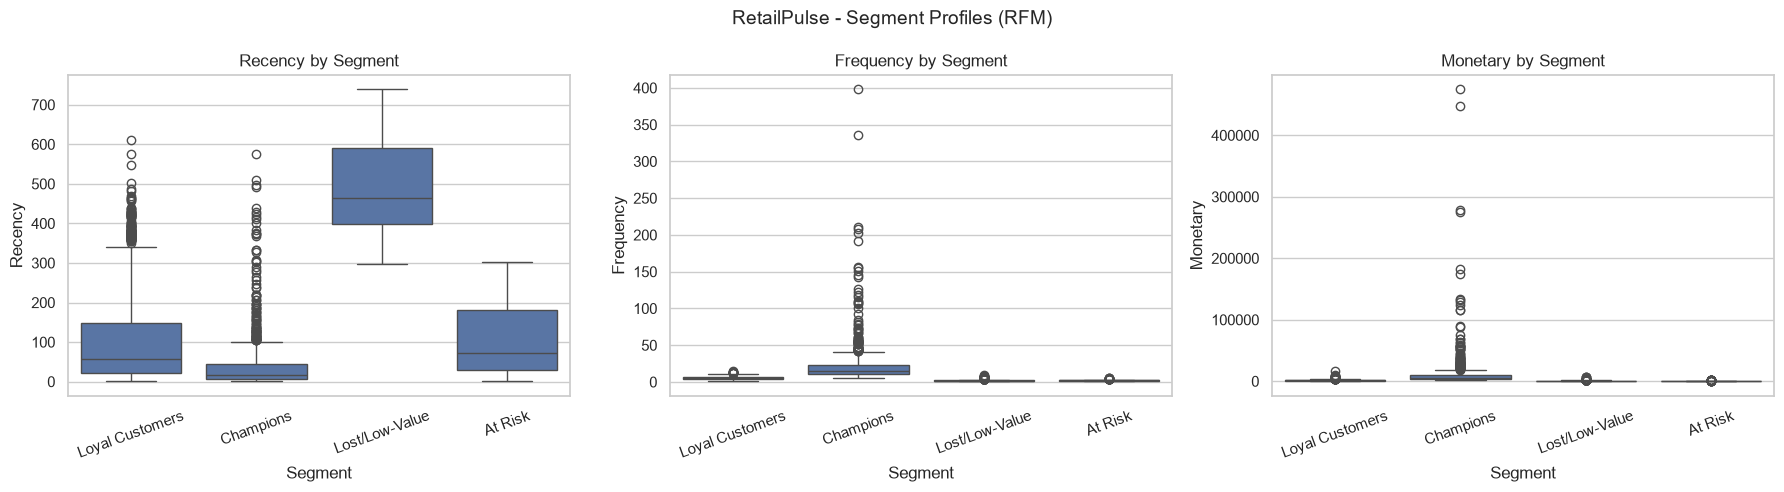

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=rfm, x="Segment", y="Recency", ax=axes[0]).set(title="Recency by Segment")
sns.boxplot(data=rfm, x="Segment", y="Frequency", ax=axes[1]).set(title="Frequency by Segment")
sns.boxplot(data=rfm, x="Segment", y="Monetary", ax=axes[2]).set(title="Monetary by Segment")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("RetailPulse - Segment Profiles (RFM)", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/segment_profiles.png", dpi=120)
plt.show()

### Segment business descriptions
- **Champions:** Recent, frequent, high-spend. Retention priority - reward loyalty, early access to new products.
- **Loyal Customers:** Regular buyers, moderate spend. Upsell/cross-sell target.
- **At Risk:** Declining recency, used to buy often. Win-back campaigns, personalized offers.
- **Lost/Low-Value:** Long recency gap, low frequency/spend. Low-cost re-engagement or deprioritize.


## 5. Save segmented customer dataset

In [11]:
rfm.to_csv("../data/processed/customer_segments.csv", index=False)
cluster_profile.to_csv("../reports/cluster_profiles.csv")
print("Saved customer_segments.csv and cluster_profiles.csv")

Saved customer_segments.csv and cluster_profiles.csv


## Summary
- K=4 selected, matching the business requirement of 4 interpretable segments, validated against elbow/silhouette curves above (not chosen arbitrarily).
- Clustering run logged to MLflow (`RetailPulse_Segmentation` experiment) with silhouette score, inertia, and the fitted model artifact.
- Segment profiles saved for use in the executive report and dashboard.

**Next:** `Day6_ChurnPrediction.ipynb`
